In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
from utils.model_saver import *
from utils.model_classes import KNNModel

PROJECT_ROOT = Path().resolve().parent.parent.parent.parent
print(f"Project root: {PROJECT_ROOT}")
PATH_DATA = PROJECT_ROOT / 'data' / 'exploded_splits'
print(f"Data: {PATH_DATA}")

GRAPH_FEATURES_PATH = PROJECT_ROOT / 'data' / 'graph_features'
TRAIN_PATH = GRAPH_FEATURES_PATH / 'final_train.parquet'
VAL_PATH = GRAPH_FEATURES_PATH / 'final_val.parquet'
TEST_PATH = GRAPH_FEATURES_PATH / 'final_test.parquet'

RANDOM_STATE = 42

import torch
# Detect device: 'cuda' if available, else 'cpu'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

# for parallelization
N_JOBS = -1 if torch.cuda.is_available() else 1

Project root: C:\Users\ivan.bernacchia\OneDrive - TINEXT SA\Documents\_Alessia\M-P6203E-DataProjects-Hackaton3_P1
Data: C:\Users\ivan.bernacchia\OneDrive - TINEXT SA\Documents\_Alessia\M-P6203E-DataProjects-Hackaton3_P1\data\exploded_splits


# KNN based Model - on graph features
By leveraging graph features (network info), we treat the problem as a supervised learning task.

To ensure code quality and reusability, we implement a custom class hierarchy:

- `BaseModel`: An abstract class that defines the blueprint for all models. It enforces the implementation of `preprocess()` method and provides standardized `train_pipeline` and `test_pipeline` methods.

- `KNNModel`: The concrete implementation of the baseline. It encapsulates the feature engineering logic (dropping non-feature columns) and stateful preprocessing (storing a `StandardScaler` to ensure the test set is scaled using training statistics).


## 1. Import dataframe with graph features

In [2]:
# splitting
df_train = pd.read_parquet(TRAIN_PATH)
df_val = pd.read_parquet(VAL_PATH)
df_test = pd.read_parquet(TEST_PATH)

print("\nSplit sizes:", {"train": len(df_train), "test": len(df_test), "val": len(df_val)})


Split sizes: {'train': 2162520, 'test': 396382, 'val': 391242}


## 2. Baseline Model

In [ ]:
KNN_baseline = KNNModel('KNN_baseline', n_neighbors=5, weights='uniform', metric='minkowski')
KNN_baseline.train_pipeline(df_train, random_state=RANDOM_STATE)

[KNN] Preprocessing data...
Label distribution:
is_reference_valid
1    0.5
0    0.5
Name: proportion, dtype: float64
[KNN] Starting training...
Selected 21625/2162520


In [ ]:
KNN_baseline.test_pipeline(df_test.sample(10000))

[KNN] Preprocessing data...
Label distribution:
is_reference_valid
1    0.5006
0    0.4994
Name: proportion, dtype: float64


KeyboardInterrupt: 

> todo comments

## 3. Hypertuning
Given the high dimensionality of embeddings and the large number of records, KNN can be computationally expensive. To optimize performance, we perform `GridSearchCV` on a representative subset of the data.

We utilize a `PredefinedSplit` strategy. Instead of standard K-fold cross-validation, we manually specify which samples belong to the training fold and which belong to the validation fold. This ensures that the model is tuned on the exact data distribution intended for validation without leakage from the training set.

In [3]:
# Drastically reduce the dataset for tuning to avoid Out-Of-Memory (OOM) crashes
# KNN with 3M rows and 128-256 features is extremely RAM-intensive
max_tuning_samples = 50000 
param_grid = {
    'n_neighbors': [5, 9, 12, 15], # Reduced number of parameters
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

[KNN_textual] Grid Search...
[KNN_textual] Preprocessing data...
Label distribution:
is_reference_valid
1    0.5
0    0.5
Name: proportion, dtype: float64
[KNN_textual] Preprocessing data...
Label distribution:
is_reference_valid
1    0.5
0    0.5
Name: proportion, dtype: float64

Starting tuning on 50000 samples...

Best parameters found:
{'metric': 'euclidean', 'n_neighbors': 12, 'weights': 'distance'}

Optimal model ready: KNeighborsClassifier(metric='euclidean', n_jobs=-1, n_neighbors=12,
                     weights='distance')
[KNN_textual] Train model with best params...
[KNN_textual] Preprocessing data...
Label distribution:
is_reference_valid
1    0.5
0    0.5
Name: proportion, dtype: float64
[KNN_textual] Starting training...
Selected 21625/2162520
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     10732
           1     1.0000    1.0000    1.0000     10893

    accuracy                         1.0000     21625
   macro avg 

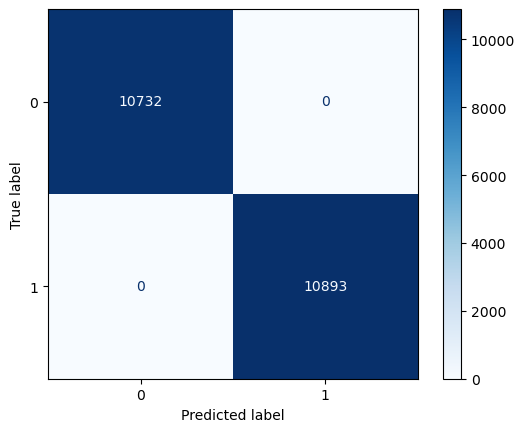

In [4]:
# tuning
KNN_graph = KNNModel("KNN_graph")
KNN_graph.hypertune_pipeline(df_train, df_val, param_grid, 
                               max_tuning_samples=max_tuning_samples,
                               scoring='f1_weighted',
                               n_jobs=N_JOBS)

## 4. Final model with best params
Once the optimal hyperparameters (number of neighbors, weight function, and distance metric) are found, the model is retrained on the full training set.

Performance is assessed using:
- Weighted F1-Score: To account for any slight imbalances in class distribution.
- Confusion Matrix: To visualize Type I and Type II errors.
- Classification Report: Providing precision, recall, and accuracy at a granular level.

[KNN_textual] Preprocessing data...
Label distribution:
is_reference_valid
1    0.515
0    0.485
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0     0.7925    0.8742    0.8314       485
           1     0.8688    0.7845    0.8245       515

    accuracy                         0.8280      1000
   macro avg     0.8307    0.8293    0.8279      1000
weighted avg     0.8318    0.8280    0.8278      1000



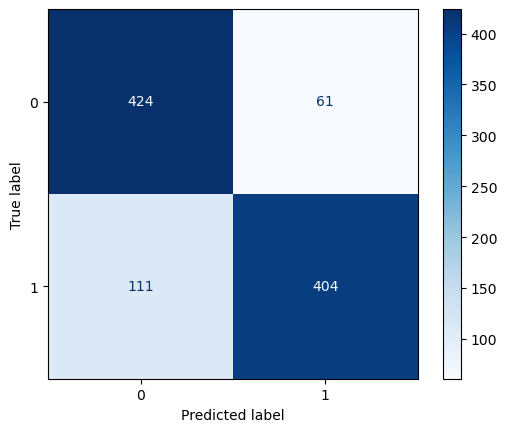

In [6]:
KNN_graph.test_pipeline(df_test.sample(1000))

## 5. Save the Model pretrained
Finally, the trained model and its associated metadata (parameters, data source name, and performance summary) are saved using a custom `save_model_artifact` utility, allowing for easy deployment or further testing.